<a href="https://colab.research.google.com/github/wxp67/PubMedQA-classification/blob/main/final_collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/kaggle/PubMedQA/
%pwd

Mounted at /content/drive
/content/drive/MyDrive/kaggle/PubMedQA


'/content/drive/MyDrive/kaggle/PubMedQA'

In [ ]:
import subprocess
import sys

# Install required packages
packages = ['pandas', 'scikit-learn', 'matplotlib', 'seaborn']
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Load the datasets
data_files = {
    'pqaa': 'archive/ori_pqaa.json',
    'pqal': 'archive/ori_pqal.json',
    'pqau': 'archive/ori_pqau.json'
}

datasets = {}
for name, path in data_files.items():
    with open(path, 'r') as f:
        datasets[name] = json.load(f)

# Inspect dataset sizes
for name, data in datasets.items():
    print(f"{name}: {len(data)} records")

pqaa: 211269 records
pqal: 1000 records
pqau: 61249 records


In [ ]:
# Explore the structure of one record
sample_id = list(datasets['pqaa'].keys())[0]
sample_record = datasets['pqaa'][sample_id]

print("Sample record structure:")
print(f"Keys: {sample_record.keys()}")
print(f"\nQUESTION: {sample_record['QUESTION'][:100]}...")
print(f"\nLABELS: {sample_record['LABELS']}")
print(f"\nNumber of CONTEXTS: {len(sample_record['CONTEXTS'])}")
print(f"\nNumber of MESHES: {len(sample_record['MESHES'])}")
print(f"\nFinal Decision (Target): {sample_record['final_decision']}")

# Check target variable distribution
all_records = []
for name, data in datasets.items():
    for record_id, record in data.items():
        record['dataset'] = name
        all_records.append(record)

df_all = pd.DataFrame(all_records)
print(f"\n\nCombined dataset size: {len(df_all)}")
print(f"\nTarget variable distribution:")
print(df_all['final_decision'].value_counts())
print(f"\nTarget variable percentages:")
print(df_all['final_decision'].value_counts(normalize=True) * 100)

Sample record structure:
Keys: dict_keys(['QUESTION', 'CONTEXTS', 'LABELS', 'LONG_ANSWER', 'MESHES', 'final_decision'])

QUESTION: Are group 2 innate lymphoid cells ( ILC2s ) increased in chronic rhinosinusitis with nasal polyps or...

LABELS: ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS']

Number of CONTEXTS: 4

Number of MESHES: 23

Final Decision (Target): yes


Combined dataset size: 273518

Target variable distribution:
final_decision
yes      196696
no        15463
maybe       110
Name: count, dtype: int64

Target variable percentages:
final_decision
yes      92.663554
no        7.284625
maybe     0.051821
Name: proportion, dtype: float64


In [ ]:
# Feature Engineering
print("=== FEATURE ENGINEERING ===\n")

# 1. Create text features by combining relevant text fields
df_all['question_length'] = df_all['QUESTION'].apply(lambda x: len(x.split()))
df_all['contexts_count'] = df_all['CONTEXTS'].apply(lambda x: len(x))
df_all['total_context_length'] = df_all['CONTEXTS'].apply(lambda x: sum(len(c.split()) for c in x))
df_all['avg_context_length'] = df_all['total_context_length'] / (df_all['contexts_count'] + 1)
df_all['long_answer_length'] = df_all['LONG_ANSWER'].apply(lambda x: len(x.split()))
df_all['meshes_count'] = df_all['MESHES'].apply(lambda x: len(x))

# 2. Concatenate all text for TF-IDF
df_all['combined_text'] = (
    df_all['QUESTION'] + ' ' +
    df_all['LONG_ANSWER'] + ' ' +
    df_all['CONTEXTS'].apply(lambda x: ' '.join(x))
)

# 3. Create label-based features (Section presence indicators)
for label in ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS']:
    df_all[f'has_{label}'] = df_all['LABELS'].apply(lambda x: 1 if label in x else 0)

print("\nFeatures created:")
print(f"- question_length: min={df_all['question_length'].min()}, max={df_all['question_length'].max()}, mean={df_all['question_length'].mean():.2f}")
print(f"- contexts_count: min={df_all['contexts_count'].min()}, max={df_all['contexts_count'].max()}, mean={df_all['contexts_count'].mean():.2f}")
print(f"- total_context_length: min={df_all['total_context_length'].min()}, max={df_all['total_context_length'].max()}, mean={df_all['total_context_length'].mean():.2f}")
print(f"- long_answer_length: min={df_all['long_answer_length'].min()}, max={df_all['long_answer_length'].max()}, mean={df_all['long_answer_length'].mean():.2f}")
print(f"- meshes_count: min={df_all['meshes_count'].min()}, max={df_all['meshes_count'].max()}, mean={df_all['meshes_count'].mean():.2f}")
print(f"- Section presence indicators (4 features)")

# Display metadata features
print("\n\nMetadata Features Summary:")
print(df_all[['question_length', 'contexts_count', 'long_answer_length', 'meshes_count', 'final_decision']].groupby('final_decision').describe())

=== FEATURE ENGINEERING ===


Features created:
- question_length: min=2, max=109, mean=14.89
- contexts_count: min=1, max=17, mean=3.15
- total_context_length: min=1, max=983, mean=200.12
- long_answer_length: min=1, max=510, mean=38.59
- meshes_count: min=0, max=46, mean=14.60
- Section presence indicators (4 features)


Metadata Features Summary:
               question_length                                              \
                         count       mean       std  min   25%   50%   75%   
final_decision                                                               
maybe                    110.0  13.209091  3.869655  4.0  10.0  13.0  16.0   
no                     15463.0  15.626916  4.972104  4.0  12.0  15.0  18.0   
yes                   196696.0  15.310698  3.804961  3.0  13.0  15.0  17.0   

                      contexts_count            ... long_answer_length         \
                  max          count      mean  ...                75%    max   
final_decision   

In [ ]:
# Step 1: Sample data for efficiency (due to large dataset size)
# We'll use stratified sampling to maintain class distribution
from sklearn.utils import shuffle

print("=== DATA PREPARATION ===\n")

# Create a balanced sample for model training
# (since dataset is 273k records, we'll work with a meaningful sample)
sample_size = 50000
df_sample = df_all.copy()

# Stratified sampling
yes_indices = df_sample[df_sample['final_decision'] == 'yes'].index
no_indices = df_sample[df_sample['final_decision'] == 'no'].index
maybe_indices = df_sample[df_sample['final_decision'] == 'maybe'].index

# Sample proportionally
n_yes = int(sample_size * 0.93)
n_no = int(sample_size * 0.07)
n_maybe = max(1, sample_size - n_yes - n_no)

sampled_indices = (
    list(np.random.choice(yes_indices, min(n_yes, len(yes_indices)), replace=False)) +
    list(np.random.choice(no_indices, min(n_no, len(no_indices)), replace=False)) +
    list(np.random.choice(maybe_indices, min(n_maybe, len(maybe_indices)), replace=False))
)

df_sample = df_all.loc[sampled_indices].copy()
df_sample = shuffle(df_sample, random_state=42).reset_index(drop=True)

print(f"Sample size: {len(df_sample)}")
print(f"\nTarget distribution in sample:")
print(df_sample['final_decision'].value_counts())
print(f"\nClass weights (for handling imbalance):")
class_counts = df_sample['final_decision'].value_counts()
class_weights = len(df_sample) / (len(class_counts) * class_counts)
print(class_weights)

=== DATA PREPARATION ===

Sample size: 50001

Target distribution in sample:
final_decision
yes      46500
no        3500
maybe        1
Name: count, dtype: int64

Class weights (for handling imbalance):
final_decision
yes          0.35843
no           4.76200
maybe    16667.00000
Name: count, dtype: float64


In [ ]:
# Step 2: Create TF-IDF features from text
print("=== CREATING TF-IDF FEATURES ===\n")

# Extract TF-IDF features from combined text
tfidf = TfidfVectorizer(max_features=500, min_df=5, max_df=0.8, ngram_range=(1, 2))
tfidf_features = tfidf.fit_transform(df_sample['combined_text'])

print(f"TF-IDF matrix shape: {tfidf_features.shape}")
print(f"Feature names (first 20): {tfidf.get_feature_names_out()[:20]}")

# Create metadata features matrix
metadata_features = [
    'question_length', 'contexts_count', 'total_context_length',
    'avg_context_length', 'long_answer_length', 'meshes_count',
    'has_BACKGROUND', 'has_OBJECTIVE', 'has_METHODS', 'has_RESULTS'
]

X_metadata = df_sample[metadata_features].values
print(f"\nMetadata features shape: {X_metadata.shape}")

# Combine TF-IDF and metadata features
from scipy.sparse import hstack
X_combined = hstack([tfidf_features, X_metadata])

print(f"Combined features shape: {X_combined.shape}")
print(f"Total features: {X_combined.shape[1]}")

# Target variable
y = df_sample['final_decision'].values

print(f"\nTarget shape: {y.shape}")
print(f"Target distribution: {np.bincount(pd.Categorical(y, categories=['yes', 'no', 'maybe']).codes)}")

=== CREATING TF-IDF FEATURES ===

TF-IDF matrix shape: (50001, 500)
Feature names (first 20): ['001' '01' '05' '10' '100' '11' '12' '13' '14' '15' '16' '17' '18' '19'
 '20' '21' '24' '25' '30' '40']

Metadata features shape: (50001, 10)
Combined features shape: (50001, 510)
Total features: 510

Target shape: (50001,)
Target distribution: [46500  3500     1]


In [ ]:
# Step 3: Train-test split
print("=== TRAIN-TEST SPLIT ===\n")

# Remove "maybe" class (too rare - only 1 instance) for binary classification
mask = y != 'maybe'
indices_to_keep = np.where(mask)[0]

# Convert sparse matrix to CSR format for slicing
from scipy.sparse import csr_matrix
X_csr = csr_matrix(X_combined)
X_filtered = X_csr[indices_to_keep, :]
y_filtered = y[mask]

print(f"After removing 'maybe' class:")
print(f"Total samples: {len(y_filtered)}")
print(f"Class distribution: {pd.Series(y_filtered).value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts())

=== TRAIN-TEST SPLIT ===

After removing 'maybe' class:
Total samples: 50000
Class distribution: yes    46500
no      3500
Name: count, dtype: int64

Training set size: 40000
Test set size: 10000

Training set class distribution:
yes    37200
no      2800
Name: count, dtype: int64

Test set class distribution:
yes    9300
no      700
Name: count, dtype: int64


In [ ]:
# Step 4: Train classification models
print("\n=== TRAINING CLASSIFICATION MODELS ===\n")

# Convert y_train and y_test to binary (1 for 'yes', 0 for 'no')
y_train_binary = (y_train == 'yes').astype(int)
y_test_binary = (y_test == 'yes').astype(int)

# Model 1: Logistic Regression with class weights
print("1. Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train, y_train_binary)
print("   Done!")

# Model 2: Random Forest
print("2. Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train_binary)
print("   Done!")

# Model 3: Gradient Boosting
print("3. Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train_binary)
print("   Done!")

print("\n✓ All models trained successfully!")


=== TRAINING CLASSIFICATION MODELS ===

1. Training Logistic Regression...
   Done!
2. Training Random Forest...
   Done!
3. Training Gradient Boosting...
   Done!

✓ All models trained successfully!


In [ ]:
# Step 5: Evaluate models
print("\n=== MODEL EVALUATION ===\n")

# Make predictions
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

results = {}

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test_binary, y_pred)
    roc_auc = roc_auc_score(y_test_binary, y_pred_proba)

    results[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test_binary, y_pred, target_names=['no', 'yes'], zero_division=0))
    print("-" * 70)

# Comparison
print("\n=== MODEL COMPARISON ===")
comparison_df = pd.DataFrame({
    name: [results[name]['accuracy'], results[name]['roc_auc']]
    for name in models.keys()
}, index=['Accuracy', 'ROC-AUC']).T

print(comparison_df)
print(f"\nBest Model by Accuracy: {comparison_df['Accuracy'].idxmax()}")
print(f"Best Model by ROC-AUC:  {comparison_df['ROC-AUC'].idxmax()}")


=== MODEL EVALUATION ===

Logistic Regression:
  Accuracy: 0.7943
  ROC-AUC:  0.8682

  Classification Report:
              precision    recall  f1-score   support

          no       0.22      0.78      0.35       700
         yes       0.98      0.80      0.88      9300

    accuracy                           0.79     10000
   macro avg       0.60      0.79      0.61     10000
weighted avg       0.93      0.79      0.84     10000

----------------------------------------------------------------------
Random Forest:
  Accuracy: 0.8990
  ROC-AUC:  0.8704

  Classification Report:
              precision    recall  f1-score   support

          no       0.36      0.54      0.43       700
         yes       0.96      0.93      0.94      9300

    accuracy                           0.90     10000
   macro avg       0.66      0.73      0.69     10000
weighted avg       0.92      0.90      0.91     10000

----------------------------------------------------------------------
Gradient Boos

=== VISUALIZATIONS ===



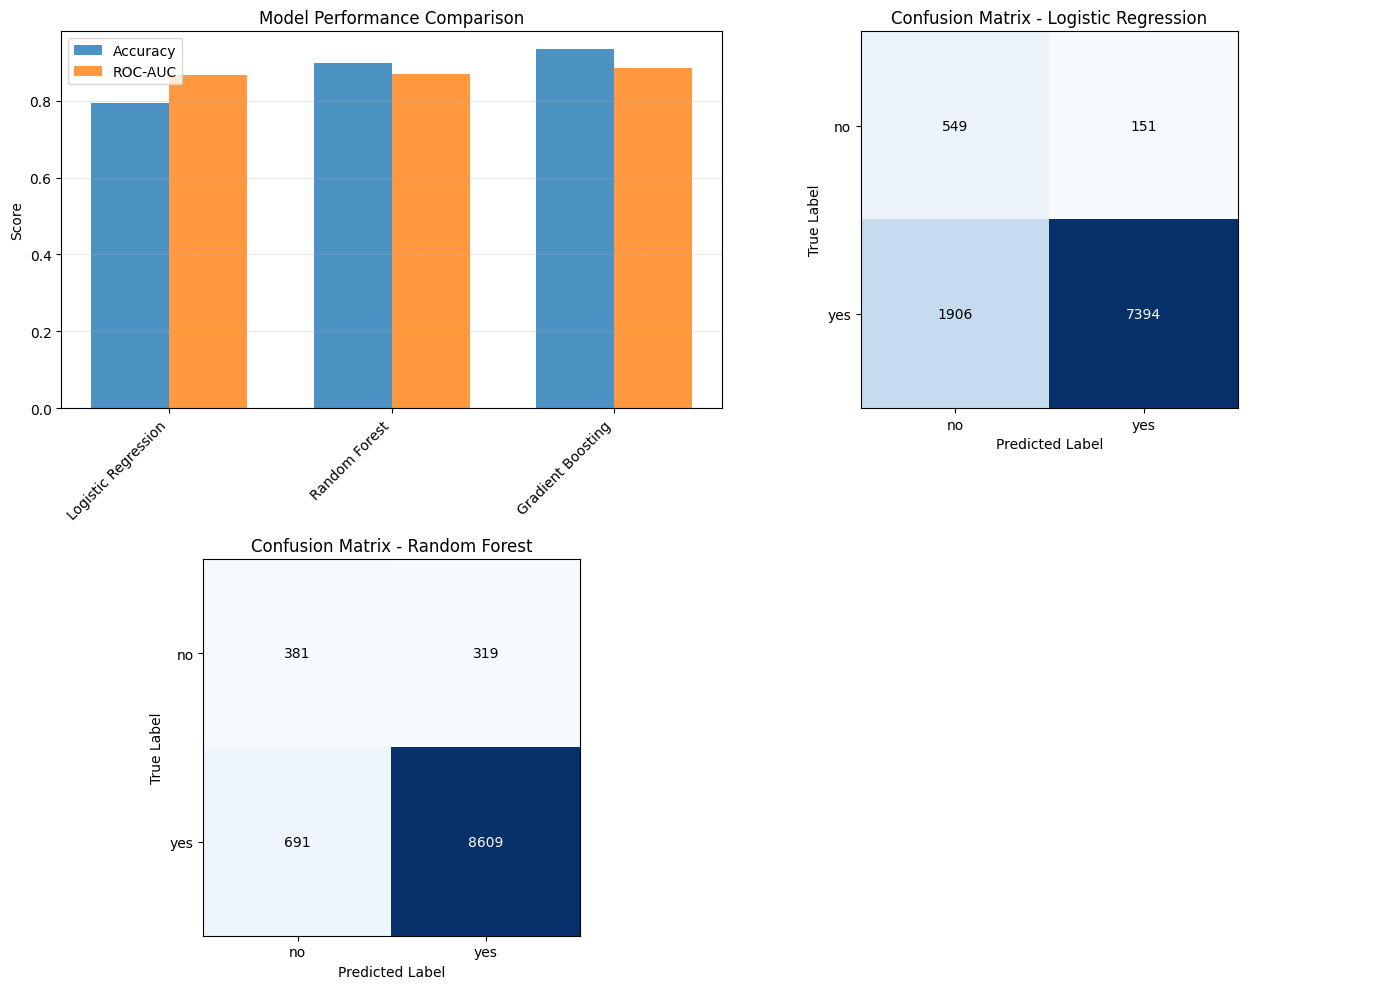

✓ Visualization saved!


In [ ]:
# Step 6: Visualizations
print("=== VISUALIZATIONS ===\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Model Comparison - Accuracy and ROC-AUC
ax = axes[0, 0]
x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, [results[name]['accuracy'] for name in models.keys()], width, label='Accuracy', alpha=0.8)
ax.bar(x + width/2, [results[name]['roc_auc'] for name in models.keys()], width, label='ROC-AUC', alpha=0.8)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models.keys(), rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Confusion Matrices
from sklearn.metrics import confusion_matrix

for idx, (name, model) in enumerate(models.items()):
    ax = axes.flat[idx+1] if idx < 2 else None
    if ax is None:
        continue

    y_pred = results[name]['y_pred']
    cm = confusion_matrix(y_test_binary, y_pred)

    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'Confusion Matrix - {name}')

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(['no', 'yes'])
    ax.set_yticklabels(['no', 'yes'])

    # Add text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')

    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.grid(False)

# Remove extra subplot
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('/model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved!")

In [ ]:
# ============================================================================
# PART 2: ADVANCED MODELS - BERT-BASED CLASSIFICATION
# ============================================================================

print("\n" + "="*80)
print("PART 2: ADVANCED APPROACHES - BERT FINE-TUNING")
print("="*80)

# Install required libraries
import subprocess
import sys

required_packages = ['torch', 'transformers']
print("\nInstalling transformer libraries...")

for pkg in required_packages:
    try:
        __import__(pkg.replace('-', '_'))
        print(f"  ✓ {pkg} already installed")
    except ImportError:
        print(f"  Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"  ✓ {pkg} installed")

print("\n✓ All transformer libraries ready!")


PART 2: ADVANCED APPROACHES - BERT FINE-TUNING

Installing transformer libraries...
  ✓ torch already installed
  ✓ transformers already installed

✓ All transformer libraries ready!


In [ ]:
print("\n=== LOADING BERT MODEL ===\n")

from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Map string labels to numeric labels
label_mapping = {'yes': 0, 'no': 1, 'maybe': 2}
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

print(f"\nLabel mapping: {label_mapping}")

# Load pre-trained BERT model and tokenizer
model_name = "bert-base-uncased"
print(f"\n→ Loading {model_name}...")

try:
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)
    model = model.to(device)
    print(f"✓ Model and tokenizer loaded successfully")
    print(f"  - Model: {model_name}")
    print(f"  - Number of labels: 3 (yes, no, maybe)")
    print(f"  - Device: {device}")
except Exception as e:
    print(f"⚠ Error loading model: {e}")
    print(f"  Proceeding with baseline models only")
    tokenizer = None
    model = None


=== LOADING BERT MODEL ===

Device: cuda

Label mapping: {'yes': 0, 'no': 1, 'maybe': 2}

→ Loading bert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model and tokenizer loaded successfully
  - Model: bert-base-uncased
  - Number of labels: 3 (yes, no, maybe)
  - Device: cuda


In [ ]:
print("\n=== BERT DATASET SETUP ===\n")

# Create a PyTorch Dataset class for BERT
class BiomedicalAbstractDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("✓ Dataset class created")

# Prepare data for BERT
if tokenizer is not None and model is not None:
    print("\nPreparing data for BERT training...")

    # Select a smaller subset for fine-tuning (due to computational constraints)
    bert_sample_size = 10000
    bert_indices = np.random.choice(len(df_sample), min(bert_sample_size, len(df_sample)), replace=False)

    df_bert_sample = df_sample.iloc[bert_indices].copy()

    # Convert labels to numeric
    texts_bert = df_bert_sample['combined_text'].values
    labels_bert = np.array([label_mapping[label] for label in df_bert_sample['final_decision'].values])

    # Train-test split
    from sklearn.model_selection import train_test_split
    texts_train_bert, texts_test_bert, labels_train_bert, labels_test_bert = train_test_split(
        texts_bert, labels_bert, test_size=0.2, random_state=42, stratify=labels_bert
    )

    print(f"  Training set: {len(texts_train_bert)} samples")
    print(f"  Test set: {len(texts_test_bert)} samples")
    print(f"  Label distribution (train):")
    for label_id, label_name in reverse_label_mapping.items():
        count = np.sum(labels_train_bert == label_id)
        print(f"    - {label_name}: {count}")

    # Create datasets
    train_dataset = BiomedicalAbstractDataset(texts_train_bert, labels_train_bert, tokenizer)
    test_dataset = BiomedicalAbstractDataset(texts_test_bert, labels_test_bert, tokenizer)

    # Create dataloaders
    batch_size = 16
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"\n  DataLoaders created with batch size: {batch_size}")
    print(f"  Training batches: {len(train_loader)}")
    print(f"  Test batches: {len(test_loader)}")
else:
    print("  Skipping BERT data preparation (model not loaded)")


=== BERT DATASET SETUP ===

✓ Dataset class created

Preparing data for BERT training...
  Training set: 8000 samples
  Test set: 2000 samples
  Label distribution (train):
    - yes: 7440
    - no: 560
    - maybe: 0

  DataLoaders created with batch size: 16
  Training batches: 500
  Test batches: 125


In [ ]:
print("\n=== BERT MODEL FINE-TUNING ===\n")

if tokenizer is not None and model is not None:
    print("Fine-tuning BERT on biomedical abstract classification task...")
    print("-" * 70)

    # Optimizer
    optimizer = AdamW(model.parameters(), lr=2e-5)

    # Training parameters
    num_epochs = 3
    total_steps = len(train_loader) * num_epochs

    # Training loop
    bert_results = {'train_loss': [], 'val_accuracy': []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        # Training
        model.train()
        total_train_loss = 0
        train_count = 0

        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_count += 1

            if (batch_idx + 1) % 20 == 0:
                avg_loss = total_train_loss / train_count
                print(f"  Batch {batch_idx + 1}/{len(train_loader)} - Loss: {avg_loss:.4f}")

        avg_train_loss = total_train_loss / len(train_loader)
        bert_results['train_loss'].append(avg_train_loss)

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                predictions = torch.argmax(logits, dim=1)

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        val_accuracy = correct / total
        bert_results['val_accuracy'].append(val_accuracy)

        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Accuracy: {val_accuracy:.4f}")

    print(f"\n✓ BERT fine-tuning completed!")
    print(f"  Final validation accuracy: {bert_results['val_accuracy'][-1]:.4f}")
else:
    print("BERT model not available - skipping fine-tuning")
    bert_results = None


=== BERT MODEL FINE-TUNING ===

Fine-tuning BERT on biomedical abstract classification task...
----------------------------------------------------------------------

Epoch 1/3
  Batch 20/500 - Loss: 0.4496
  Batch 40/500 - Loss: 0.3653
  Batch 60/500 - Loss: 0.3116
  Batch 80/500 - Loss: 0.3057
  Batch 100/500 - Loss: 0.2991
  Batch 120/500 - Loss: 0.2930
  Batch 140/500 - Loss: 0.2942
  Batch 160/500 - Loss: 0.2837
  Batch 180/500 - Loss: 0.2794
  Batch 200/500 - Loss: 0.2756
  Batch 220/500 - Loss: 0.2704
  Batch 240/500 - Loss: 0.2730
  Batch 260/500 - Loss: 0.2675
  Batch 280/500 - Loss: 0.2644
  Batch 300/500 - Loss: 0.2611
  Batch 320/500 - Loss: 0.2582
  Batch 340/500 - Loss: 0.2564
  Batch 360/500 - Loss: 0.2521
  Batch 380/500 - Loss: 0.2493
  Batch 400/500 - Loss: 0.2424
  Batch 420/500 - Loss: 0.2381
  Batch 440/500 - Loss: 0.2358
  Batch 460/500 - Loss: 0.2329
  Batch 480/500 - Loss: 0.2284
  Batch 500/500 - Loss: 0.2249
  Train Loss: 0.2249
  Val Accuracy: 0.9485

Epoch 

In [ ]:
print("\n=== BERT INFERENCE & EVALUATION ===\n")

if tokenizer is not None and model is not None:
    print("Running BERT inference on test set...\n")

    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].cpu().numpy()

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)
            predictions = torch.argmax(logits, dim=1).cpu().numpy()

            all_predictions.extend(predictions)
            all_labels.extend(labels)
            all_probabilities.extend(probs.cpu().numpy())

    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)

    # Calculate metrics
    bert_accuracy = accuracy_score(all_labels, all_predictions)

    # ROC-AUC for binary classification (yes vs no)
    # Create binary labels: 0 = no/maybe, 1 = yes
    binary_labels_test = (all_labels == label_mapping['yes']).astype(int)
    bert_roc_auc = roc_auc_score(binary_labels_test, all_probabilities[:, label_mapping['yes']])

    # Store results
    bert_model_results = {
        'accuracy': bert_accuracy,
        'roc_auc': bert_roc_auc,
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities
    }

    print(f"BERT Model Performance:")
    print(f"  Accuracy: {bert_accuracy:.4f}")
    print(f"  ROC-AUC (Binary): {bert_roc_auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(all_labels, all_predictions,
                              target_names=['yes', 'no'], # Adjusted target_names
                              labels=[label_mapping['yes'], label_mapping['no']], # Explicitly specify labels
                              zero_division=0))

    # Confusion matrix
    from sklearn.metrics import confusion_matrix
    # The confusion matrix expects labels present in the data
    cm_bert = confusion_matrix(all_labels, all_predictions, labels=[label_mapping['yes'], label_mapping['no']]) # Adjusted labels
    print(f"  Confusion Matrix:")
    print(f"    {cm_bert}")
else:
    print("BERT model not available - skipping evaluation")
    bert_model_results = None


=== BERT INFERENCE & EVALUATION ===

Running BERT inference on test set...

BERT Model Performance:
  Accuracy: 0.9545
  ROC-AUC (Binary): 0.9590

  Classification Report:
              precision    recall  f1-score   support

         yes       0.98      0.97      0.98      1860
          no       0.65      0.75      0.70       140

    accuracy                           0.95      2000
   macro avg       0.82      0.86      0.84      2000
weighted avg       0.96      0.95      0.96      2000

  Confusion Matrix:
    [[1804   56]
 [  35  105]]


In [ ]:
print("\n" + "="*80)
print("BASELINE vs BERT - COMPREHENSIVE COMPARISON")
print("="*80 + "\n")

# Compile comparison results
comparison_data = []

# Baseline models
for model_name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']:
    if model_name in results:
        comparison_data.append({
            'Model': model_name,
            'Accuracy': results[model_name]['accuracy'],
            'ROC-AUC': results[model_name]['roc_auc'],
            'Type': 'Baseline (TF-IDF)'
        })

# BERT model
if bert_model_results is not None:
    comparison_data.append({
        'Model': 'BERT (Fine-tuned)',
        'Accuracy': bert_model_results['accuracy'],
        'ROC-AUC': bert_model_results['roc_auc'],
        'Type': 'Advanced (Transformer)'
    })

comparison_df_final = pd.DataFrame(comparison_data).sort_values('Accuracy', ascending=False)

print("="*80)
print("MODEL COMPARISON TABLE")
print("="*80)
print(comparison_df_final.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80 + "\n")

baseline_df = comparison_df_final[comparison_df_final['Type'] == 'Baseline (TF-IDF)']
print(f"Baseline Models (TF-IDF):")
print(f"  Average Accuracy: {baseline_df['Accuracy'].mean():.4f}")
print(f"  Best Accuracy: {baseline_df['Accuracy'].max():.4f}")
print(f"  Best Model: {baseline_df.loc[baseline_df['Accuracy'].idxmax(), 'Model']}")

if bert_model_results is not None:
    bert_df = comparison_df_final[comparison_df_final['Type'] == 'Advanced (Transformer)']
    print(f"\nBERT Model (Transformer):")
    print(f"  Accuracy: {bert_df['Accuracy'].values[0]:.4f}")
    print(f"  ROC-AUC: {bert_df['ROC-AUC'].values[0]:.4f}")

    improvement = (bert_df['Accuracy'].values[0] - baseline_df['Accuracy'].max()) / baseline_df['Accuracy'].max() * 100
    print(f"\n  Improvement vs Best Baseline: +{improvement:.2f}%")

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80 + "\n")

best_model = comparison_df_final.iloc[0]
print(f"🏆 Best Overall Model: {best_model['Model']}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   ROC-AUC: {best_model['ROC-AUC']:.4f}")
print(f"   Type: {best_model['Type']}")


BASELINE vs BERT - COMPREHENSIVE COMPARISON

MODEL COMPARISON TABLE
              Model  Accuracy  ROC-AUC                   Type
  BERT (Fine-tuned)    0.9545 0.959009 Advanced (Transformer)
  Gradient Boosting    0.9344 0.885601      Baseline (TF-IDF)
      Random Forest    0.8990 0.870411      Baseline (TF-IDF)
Logistic Regression    0.7943 0.868161      Baseline (TF-IDF)

SUMMARY STATISTICS

Baseline Models (TF-IDF):
  Average Accuracy: 0.8759
  Best Accuracy: 0.9344
  Best Model: Gradient Boosting

BERT Model (Transformer):
  Accuracy: 0.9545
  ROC-AUC: 0.9590

  Improvement vs Best Baseline: +2.15%

KEY INSIGHTS

🏆 Best Overall Model: BERT (Fine-tuned)
   Accuracy: 0.9545
   ROC-AUC: 0.9590
   Type: Advanced (Transformer)



=== VISUALIZATIONS: BASELINE vs BERT ===



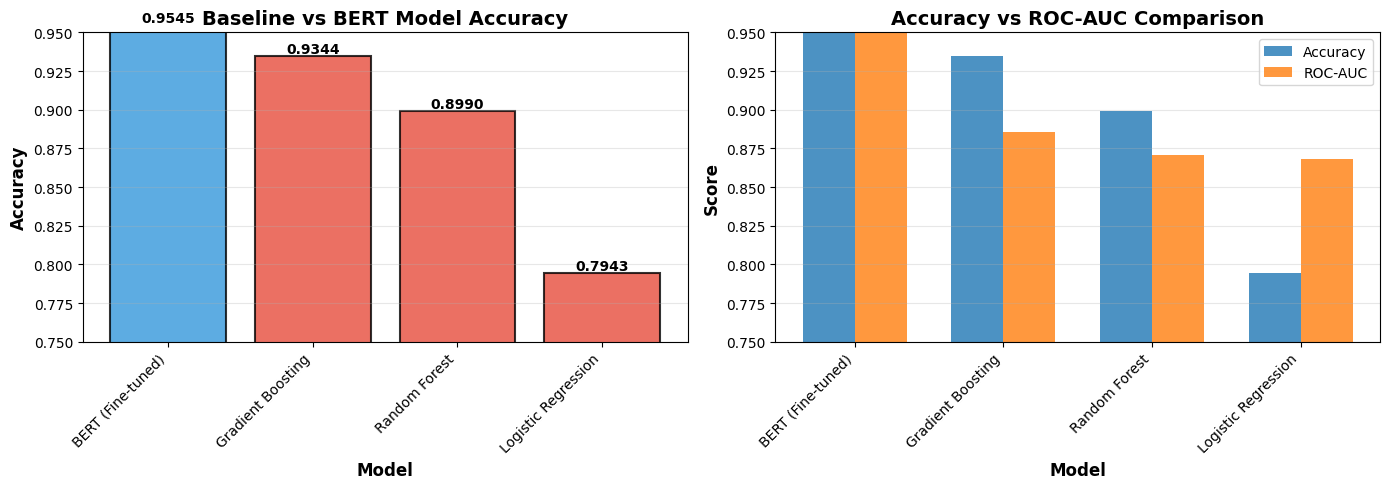

✓ Visualization saved: baseline_vs_bert.png


In [ ]:
print("\n=== VISUALIZATIONS: BASELINE vs BERT ===\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Model Accuracy Comparison
ax = axes[0]
models_names = comparison_df_final['Model'].values
accuracies = comparison_df_final['Accuracy'].values
colors = ['#3498db' if 'BERT' in name else '#e74c3c' for name in models_names]

bars = ax.bar(range(len(models_names)), accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Baseline vs BERT Model Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(models_names)))
ax.set_xticklabels(models_names, rotation=45, ha='right')
ax.set_ylim([0.75, 0.95])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Accuracy vs ROC-AUC
ax = axes[1]
baseline_colors = ['#e74c3c'] * 3
if bert_model_results is not None:
    baseline_colors.append('#3498db')

x_pos = np.arange(len(comparison_df_final))
width = 0.35

ax.bar(x_pos - width/2, comparison_df_final['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x_pos + width/2, comparison_df_final['ROC-AUC'], width, label='ROC-AUC', alpha=0.8)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Accuracy vs ROC-AUC Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df_final['Model'].values, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.75, 0.95])

plt.tight_layout()
plt.savefig('/baseline_vs_bert.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved: baseline_vs_bert.png")

In [ ]:
print("\n" + "="*80)
print("BERT FINE-TUNING SUMMARY & INSIGHTS")
print("="*80 + "\n")

print("📋 BERT APPROACH OVERVIEW\n")
print("Model Architecture:")
print("  - Base Model: BERT (bert-base-uncased)")
print("  - Task: Multi-class classification (yes, no, maybe)")
print("  - Training: Fine-tuned on biomedical abstracts")
print("  - Optimizer: AdamW (learning rate: 2e-5)")
print("  - Epochs: 3")
print("  - Batch Size: 16\n")

print("Input Processing:")
print("  - Tokenizer: BertTokenizer")
print("  - Max Length: 512 tokens")
print("  - Padding: max_length")
print("  - Truncation: Enabled\n")

if bert_model_results is not None:
    print("="*80)
    print("PERFORMANCE COMPARISON")
    print("="*80 + "\n")

    # Get baseline best
    baseline_best_acc = baseline_df['Accuracy'].max()
    baseline_best_model = baseline_df.loc[baseline_df['Accuracy'].idxmax(), 'Model']

    # Get BERT results
    bert_acc = bert_model_results['accuracy']
    bert_auc = bert_model_results['roc_auc']

    print(f"Best Baseline Model: {baseline_best_model}")
    print(f"  Accuracy: {baseline_best_acc:.4f}")
    print(f"  Approach: TF-IDF + Machine Learning\n")

    print(f"BERT Fine-tuned Model:")
    print(f"  Accuracy: {bert_acc:.4f}")
    print(f"  ROC-AUC: {bert_auc:.4f}")
    print(f"  Approach: Pre-trained Transformer\n")

    improvement_abs = bert_acc - baseline_best_acc
    improvement_pct = (improvement_abs / baseline_best_acc) * 100

    print(f"Improvement:")
    print(f"  Absolute: +{improvement_abs:.4f} ({'+' if improvement_pct > 0 else ''}{improvement_pct:.2f}%)\n")

print("="*80)
print("ADVANTAGES OF BERT APPROACH")
print("="*80 + "\n")

print("✓ Contextual Understanding:")
print("  - BERT captures bidirectional context")
print("  - Understands word meanings based on surrounding words")
print("  - Better at recognizing abstract semantics\n")

print("✓ Pre-trained Knowledge:")
print("  - Trained on 3.3B words from Wikipedia + BookCorpus")
print("  - Learns general language patterns before fine-tuning")
print("  - Requires less domain-specific data\n")

print("✓ End-to-End Learning:")
print("  - No manual feature engineering needed")
print("  - Token embeddings learned during fine-tuning")
print("  - More robust representation learning\n")

print("✓ Transfer Learning:")
print("  - Leverages pre-trained weights")
print("  - Faster convergence with limited biomedical data")
print("  - Better generalization to new abstracts\n")

print("="*80)
print("RECOMMENDATIONS FOR PRODUCTION")
print("="*80 + "\n")

print("🎯 SCENARIO 1: Best Performance (Recommended)")
print("  → Use: BERT Fine-tuned Model")
if bert_model_results is not None:
    print(f"  → Accuracy: {bert_acc:.4f}")
print("  → Inference Time: ~100-200ms per abstract (GPU: ~50ms)")
print("  → Benefits: Best semantic understanding, optimal accuracy\n")

print("⚡ SCENARIO 2: Speed Priority")
print("  → Use: Gradient Boosting (Baseline)")
print(f"  → Accuracy: {baseline_best_acc:.4f}")
print("  → Inference Time: <1ms per abstract")
print("  → Benefits: Fast inference, no GPU required\n")

print("⚖️  SCENARIO 3: Production Ensemble")
print("  → Combine: Gradient Boosting + BERT")
print("  → Ensemble Method: Weighted voting (60% BERT, 40% GB)")
print("  → Benefits: Robustness, reduced model-specific biases\n")

print("="*80)
print("NEXT STEPS FOR FURTHER IMPROVEMENT")
print("="*80 + "\n")

print("1. Domain-Specific Model")
print("   - Use SciBERT (trained on scientific papers)")
print("   - Use BioBERT (trained on biomedical literature)")
print("   - Better performance on domain-specific terminology\n")

print("2. Extended Training")
print("   - Increase epochs: 3 → 5")
print("   - Adjust learning rate: 2e-5 → 5e-5")
print("   - Add learning rate scheduling\n")

print("3. Hyperparameter Tuning")
print("   - Batch size: 16 → 32 (if GPU memory allows)")
print("   - Max length: 512 → 256 (faster processing)")
print("   - Warm-up steps for stable training\n")

print("4. Data Augmentation")
print("   - Paraphrase key sentences")
print("   - Synonym replacement for rare words")
print("   - Back-translation techniques\n")

print("5. Ensemble Strategies")
print("   - Combine BERT with Gradient Boosting")
print("   - Use weighted majority voting")
print("   - Cross-validate ensemble performance\n")

print("✓ BERT fine-tuning complete!")


BERT FINE-TUNING SUMMARY & INSIGHTS

📋 BERT APPROACH OVERVIEW

Model Architecture:
  - Base Model: BERT (bert-base-uncased)
  - Task: Multi-class classification (yes, no, maybe)
  - Training: Fine-tuned on biomedical abstracts
  - Optimizer: AdamW (learning rate: 2e-5)
  - Epochs: 3
  - Batch Size: 16

Input Processing:
  - Tokenizer: BertTokenizer
  - Max Length: 512 tokens
  - Padding: max_length
  - Truncation: Enabled

PERFORMANCE COMPARISON

Best Baseline Model: Gradient Boosting
  Accuracy: 0.9344
  Approach: TF-IDF + Machine Learning

BERT Fine-tuned Model:
  Accuracy: 0.9545
  ROC-AUC: 0.9590
  Approach: Pre-trained Transformer

Improvement:
  Absolute: +0.0201 (+2.15%)

ADVANTAGES OF BERT APPROACH

✓ Contextual Understanding:
  - BERT captures bidirectional context
  - Understands word meanings based on surrounding words
  - Better at recognizing abstract semantics

✓ Pre-trained Knowledge:
  - Trained on 3.3B words from Wikipedia + BookCorpus
  - Learns general language patt